<a href="https://colab.research.google.com/github/Rokaia-Rezk/one-p/blob/main/latest_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
df=pd.read_csv("/content/retail_store_sales new project.csv")
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


**Data identification**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.size

138325

In [ ]:
df.shape

(12575, 11)

In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


-------------------------------------------

***Data cleaning start***






----------------------------------------------------

**Checking null values**

In [ ]:
df.nunique()

,0
Transaction ID,12575
Customer ID,25
Category,8
Item,200
Price Per Unit,25
Quantity,10
Total Spent,227
Payment Method,3
Location,2
Transaction Date,1114


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"col {col} contains: {df[col].unique()}")

col Transaction ID contains: ['TXN_6867343' 'TXN_3731986' 'TXN_9303719' ... 'TXN_5306010' 'TXN_5167298'
 'TXN_2407494']
col Customer ID contains: ['CUST_09' 'CUST_22' 'CUST_02' 'CUST_06' 'CUST_05' 'CUST_07' 'CUST_21'
 'CUST_23' 'CUST_25' 'CUST_14' 'CUST_15' 'CUST_17' 'CUST_01' 'CUST_10'
 'CUST_04' 'CUST_13' 'CUST_18' 'CUST_08' 'CUST_20' 'CUST_12' 'CUST_11'
 'CUST_19' 'CUST_16' 'CUST_24' 'CUST_03']
col Category contains: ['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']
col Item contains: ['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 nan 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT' 'Item_2_FOOD'
 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE' 'Item_7_BEV'
 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT' 'Item_25_FUR'
 'Item_14_FOOD' 'Item_22_PAT' 'Item_11_FOOD' 'Item_6_PAT' 'Item_21_EHE'
 'Item_25_BEV' 'Item_23_FOOD' 'Item_10_FUR' 'Item_11_B

**Missing values before imputation**

In [ ]:

display(df.isna().sum())

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


 **Imputing numerical columns with the mean**

In [ ]:
# Fill missing values in numerical columns with their mean
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean())

**Imputing categorical columns with the mode**

In [ ]:
# Fill missing values in 'Item' with its mode
mode_item = df['Item'].mode()[0]
df['Item'] = df['Item'].fillna(mode_item)

# Fill missing values in 'Discount Applied' with its mode
mode_discount = df['Discount Applied'].mode()[0]
df['Discount Applied'] = df['Discount Applied'].fillna(mode_discount)

/tmp/ipykernel_1419/1731373330.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Discount Applied'] = df['Discount Applied'].fillna(mode_discount)


### Missing values after imputation

In [ ]:
df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.dropna().sum()

,0
Transaction ID,TXN_6867343TXN_3731986TXN_9303719TXN_9458126TX...
Customer ID,CUST_09CUST_22CUST_02CUST_06CUST_05CUST_09CUST...
Category,PatisserieMilk ProductsButchersBeveragesFoodPa...
Item,Item_10_PATItem_17_MILKItem_12_BUTItem_16_BEVI...
Price Per Unit,293826.340256
Quantity,69619.973269
Total Spent,1630381.156545
Payment Method,Digital WalletDigital WalletCredit CardCredit ...
Location,OnlineOnlineOnlineOnlineOnlineOnlineIn-storeIn...
Transaction Date,2024-04-082023-07-232022-10-052022-05-072022-1...


**Check for duplication in values**

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
12570,False
12571,False
12572,False
12573,False


**Data display after cleaning**

In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


 **save_cleaned_data**

In [ ]:
df.to_excel('cleaned_da_ta.xlsx', index=False)

**Display** **some** ***informations***

/tmp/ipykernel_1419/1805727379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')


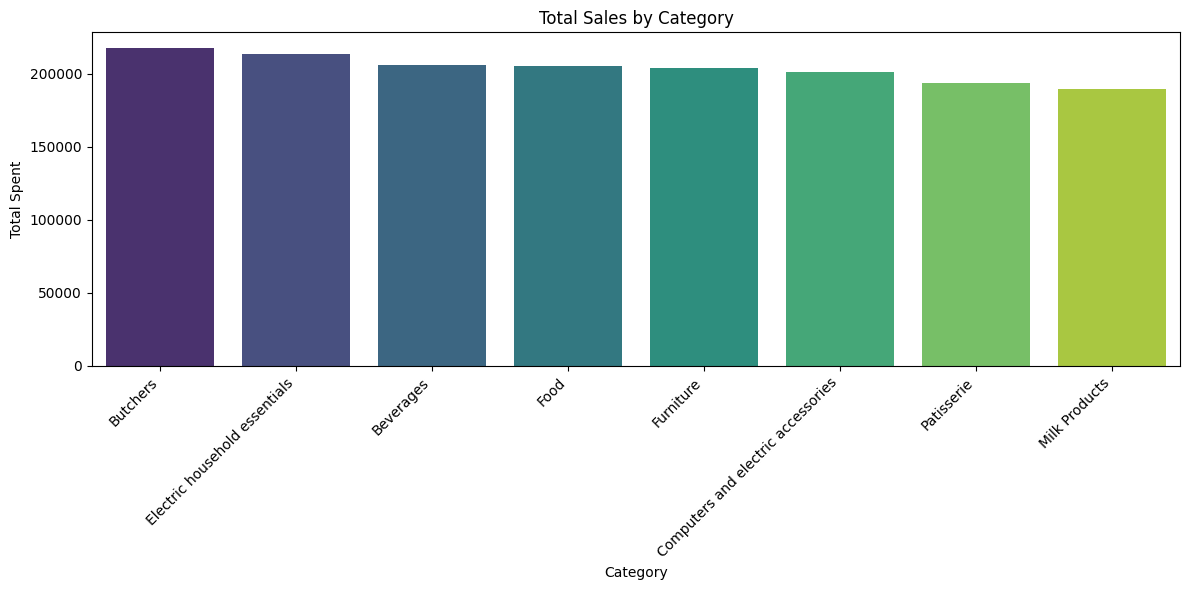

In [ ]:

# Group by 'Category' and sum 'Total Spent'
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

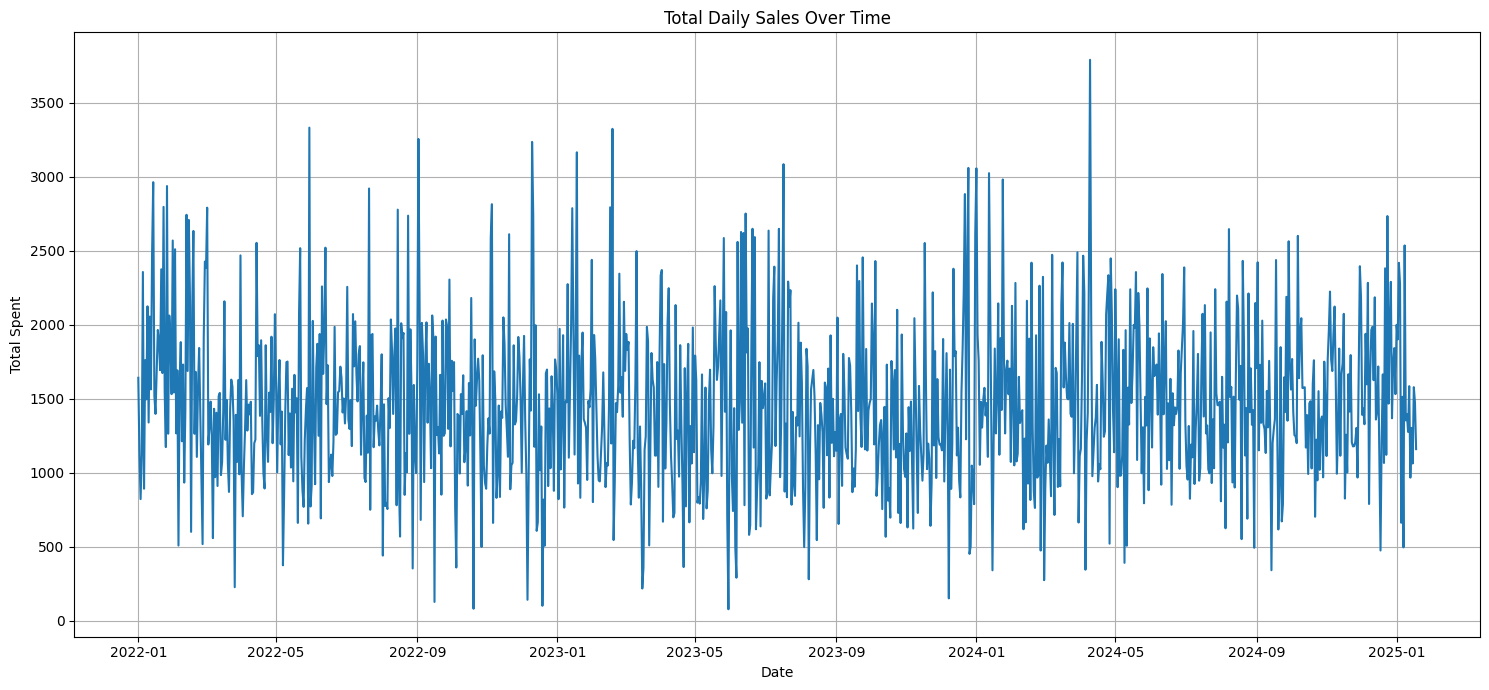

In [ ]:
# Convert 'Transaction Date' to datetime objects
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Group by date and sum 'Total Spent'
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum().reset_index()

# Create a line plot for daily sales over time
plt.figure(figsize=(15, 7))
sns.lineplot(x='Transaction Date', y='Total Spent', data=daily_sales)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Spent')
plt.grid(True)
plt.tight_layout()
plt.show()